# Basic Classification Practice

## Dataset
**Breast Cancer Wisconsin (Diagnostic)** (built into scikit-learn)

## Target
- **0** = malignant (cancer)
- **1** = benign (no cancer)

## Models
- Logistic Regression
- Gaussian Naive Bayes

> **Note:** Perceptron is excluded.

---

## Objectives

This script will:

1. Train two classification models.
2. Compute the following evaluation metrics:
   - Accuracy
   - Precision
   - Recall
   - F1-score
3. Print the confusion matrix for each model.
4. Find at least **5 incorrect predictions** and inspect why the models made those mistakes.
5. Provide a plain-language explanation of **False Positives (FP)** and **False Negatives (FN)** in the context of breast cancer diagnosis.

# Importing necessary library

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
 
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
 
RANDOM_STATE = 42

# Load and split data

In [25]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(1 - data.target, name="target")  # flip: 1 = malignant, 0 = benign
 
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, X.index, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. TRAIN MODELS + METRICS + CONFUSION MATRIX (text)

In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "Gaussian Naive Bayes": GaussianNB(),
}
 
results = {}
 
print("#" * 70)
print("# STEP 1-3: TRAIN MODELS, METRICS, CONFUSION MATRICES")
print("#" * 70)
 
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
 
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
 
    results[name] = {"model": model, "y_pred": y_pred,
                      "acc": acc, "prec": prec, "rec": rec, "f1": f1, "cm": cm}
 
    print("\n" + "=" * 70)
    print(f"MODEL: {name}")
    print("=" * 70)
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}  (of predicted malignant, how many truly are)")
    print(f"Recall   : {rec:.3f}  (of actual malignant cases, how many we caught)")
    print(f"F1 Score : {f1:.3f}")
    print("\nConfusion Matrix  (rows = actual, cols = predicted)")
    print("                 Pred: Benign(0)   Pred: Malignant(1)")
    print(f"Actual Benign(0)      {cm[0][0]:>6}            {cm[0][1]:>6}")
    print(f"Actual Malignant(1)   {cm[1][0]:>6}            {cm[1][1]:>6}")

######################################################################
# STEP 1-3: TRAIN MODELS, METRICS, CONFUSION MATRICES
######################################################################

MODEL: Logistic Regression
Accuracy : 0.965
Precision: 0.980  (of predicted malignant, how many truly are)
Recall   : 0.925  (of actual malignant cases, how many we caught)
F1 Score : 0.951

Confusion Matrix  (rows = actual, cols = predicted)
                 Pred: Benign(0)   Pred: Malignant(1)
Actual Benign(0)          89                 1
Actual Malignant(1)        4                49

MODEL: Gaussian Naive Bayes
Accuracy : 0.944
Precision: 0.959  (of predicted malignant, how many truly are)
Recall   : 0.887  (of actual malignant cases, how many we caught)
F1 Score : 0.922

Confusion Matrix  (rows = actual, cols = predicted)
                 Pred: Benign(0)   Pred: Malignant(1)
Actual Benign(0)          88                 2
Actual Malignant(1)        6                47


# 3b. CONFUSION MATRIX PLOT (image, both models side by side)


[Displaying confusion matrix plot -- close the window to continue]


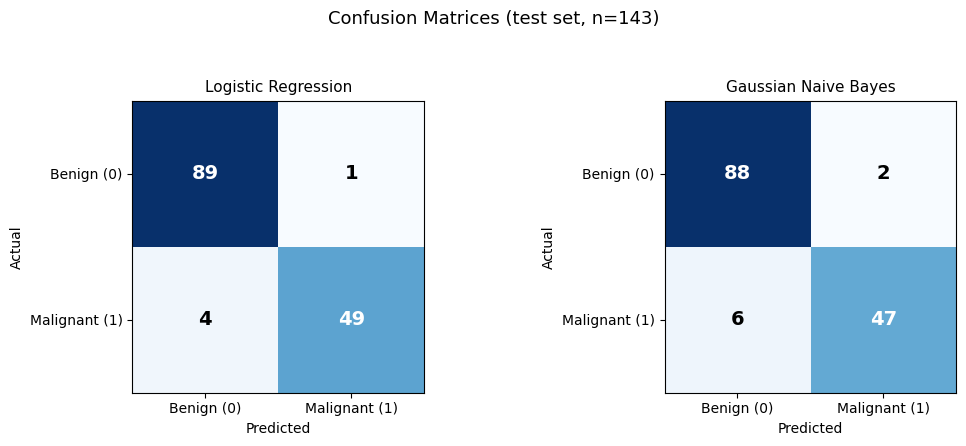

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
labels = ["Benign (0)", "Malignant (1)"]
 
for ax, (name, res) in zip(axes, results.items()):
    cm = res["cm"]
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name, fontsize=11)
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color=color, fontsize=14, fontweight="bold")
 
fig.suptitle(f"Confusion Matrices (test set, n={len(y_test)})", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.93])
print("\n[Displaying confusion matrix plot -- close the window to continue]")
plt.show()

# 4. WRONG PREDICTIONS (>=5) + EXPLANATION

In [28]:
primary = "Logistic Regression"
y_pred_primary = results[primary]["y_pred"]
wrong_mask = (y_pred_primary != y_test.values)
wrong_idx_positions = np.where(wrong_mask)[0]
 
print("\n" + "#" * 70)
print(f"# STEP 4: WRONG PREDICTIONS ({primary}) — found {wrong_mask.sum()} total")
print("#" * 70)
 
class_means = X_train.assign(target=y_train.values).groupby("target").mean()
key_features = ["mean radius", "mean texture", "mean concavity",
                 "worst radius", "worst concavity", "worst area"]
 
n_show = min(5, len(wrong_idx_positions))
for pos in wrong_idx_positions[:n_show]:
    orig_idx = idx_test[pos]
    true_label = y_test.iloc[pos]
    pred_label = y_pred_primary[pos]
    row = X_test.iloc[pos]
    proba = results[primary]["model"].predict_proba(X_test_scaled[pos].reshape(1, -1))[0]
 
    print(f"\n--- Sample index {orig_idx} ---")
    print(f"True label     : {'Malignant' if true_label == 1 else 'Benign'}")
    print(f"Predicted label: {'Malignant' if pred_label == 1 else 'Benign'}")
    print(f"Model confidence -> P(benign)={proba[0]:.3f}  P(malignant)={proba[1]:.3f}")
    print("Key feature values vs. class averages:")
    for feat in key_features:
        val = row[feat]
        mean_benign = class_means.loc[0, feat]
        mean_malig = class_means.loc[1, feat]
        print(f"   {feat:15s}: sample={val:8.2f}   benign_avg={mean_benign:8.2f}   malignant_avg={mean_malig:8.2f}")


######################################################################
# STEP 4: WRONG PREDICTIONS (Logistic Regression) — found 5 total
######################################################################

--- Sample index 215 ---
True label     : Malignant
Predicted label: Benign
Model confidence -> P(benign)=0.647  P(malignant)=0.353
Key feature values vs. class averages:
   mean radius    : sample=   13.86   benign_avg=   12.17   malignant_avg=   17.53
   mean texture   : sample=   16.93   benign_avg=   18.10   malignant_avg=   21.58
   mean concavity : sample=    0.10   benign_avg=    0.05   malignant_avg=    0.16
   worst radius   : sample=   15.75   benign_avg=   13.42   malignant_avg=   21.31
   worst concavity: sample=    0.46   benign_avg=    0.17   malignant_avg=    0.44
   worst area     : sample=  750.10   benign_avg=  563.22   malignant_avg= 1446.65

--- Sample index 455 ---
True label     : Benign
Predicted label: Malignant
Model confidence -> P(benign)=0.462  P(malig

WHY THESE FAIL (general pattern):
  - Most errors are malignant tumors predicted as benign. Their size/area
    features sit in a "gray zone" -- above the benign average but below the
    typical malignant average (early-stage / small malignant tumors).
  - The model relies heavily on size + concavity features; when a tumor's
    texture or concavity doesn't match the usual malignant profile, the
    model leans benign even if it's actually malignant.
  - This reflects genuine class overlap in the data (not a coding bug) --
    some tumors are simply borderline on the measured features.

# 5. DECISION BOUNDARY (2 features, for visual intuition)

[Displaying decision boundary plot -- close the window when done]


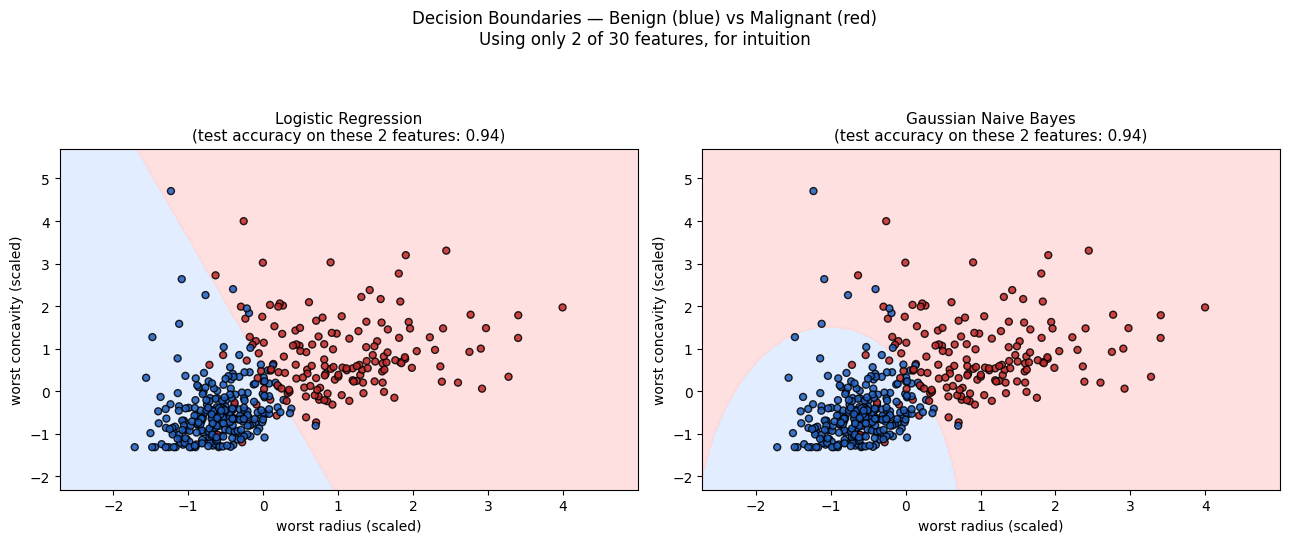

In [29]:
feat_x, feat_y = "worst radius", "worst concavity"
X2 = data.data[:, [list(data.feature_names).index(feat_x),
                    list(data.feature_names).index(feat_y)]]
y2 = 1 - data.target
 
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.25, random_state=RANDOM_STATE, stratify=y2
)
scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)
X2_test_s = scaler2.transform(X2_test)
 
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5.5))
cmap_bg = ListedColormap(["#dbe9ff", "#ffd9d9"])
cmap_pts = ListedColormap(["#1f5fbf", "#c22929"])
 
x_min, x_max = X2_train_s[:, 0].min() - 1, X2_train_s[:, 0].max() + 1
y_min, y_max = X2_train_s[:, 1].min() - 1, X2_train_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
 
models_2d = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "Gaussian Naive Bayes": GaussianNB(),
}
 
for ax, (name, model) in zip(axes2, models_2d.items()):
    model.fit(X2_train_s, y2_train)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.8)
    ax.scatter(X2_train_s[:, 0], X2_train_s[:, 1], c=y2_train, cmap=cmap_pts,
               edgecolor="k", s=25, alpha=0.85)
    acc2 = model.score(X2_test_s, y2_test)
    ax.set_title(f"{name}\n(test accuracy on these 2 features: {acc2:.2f})", fontsize=11)
    ax.set_xlabel(f"{feat_x} (scaled)")
    ax.set_ylabel(f"{feat_y} (scaled)")
 
fig2.suptitle("Decision Boundaries — Benign (blue) vs Malignant (red)\n"
              "Using only 2 of 30 features, for intuition", fontsize=12)
fig2.tight_layout(rect=[0, 0, 1, 0.92])
print("[Displaying decision boundary plot -- close the window when done]")
plt.show()

# 6-7. FALSE POSITIVES vs FALSE NEGATIVES + WHICH METRIC MATTERS MOST

In [31]:

print("# STEP 6-7: FP vs FN, AND CHOOSING THE RIGHT METRIC")

print("""
FALSE POSITIVE (predicted malignant, actually benign):
  -> Unnecessary biopsy, stress, extra cost. Bad, but recoverable.
 
FALSE NEGATIVE (predicted benign, actually malignant):
  -> Real cancer goes undetected and untreated. Potentially fatal, and much
     harder to recover from than a false alarm.
 
MOST IMPORTANT METRIC HERE: RECALL (on the malignant/positive class)
  Because missing a real cancer (FN) is far more costly than a false alarm
  (FP), we should prioritize catching as many true malignant cases as
  possible, even if it costs some precision (more false alarms).
 
  Comparing the two models on this basis:
""")
for name, res in results.items():
    print(f"  {name:22s} recall = {res['rec']:.3f}   precision = {res['prec']:.3f}")
 
best_recall = max(results, key=lambda k: results[k]["rec"])
print(f"\n  -> '{best_recall}' has the higher recall and is the better choice "
      f"for this problem, since catching more real cancers matters more than "
      f"minimizing false alarms. In practice, one could also lower its "
      f"decision threshold below 0.5 to push recall even higher.")
 
print("\nDone.")

# STEP 6-7: FP vs FN, AND CHOOSING THE RIGHT METRIC

FALSE POSITIVE (predicted malignant, actually benign):
  -> Unnecessary biopsy, stress, extra cost. Bad, but recoverable.

FALSE NEGATIVE (predicted benign, actually malignant):
  -> Real cancer goes undetected and untreated. Potentially fatal, and much
     harder to recover from than a false alarm.

MOST IMPORTANT METRIC HERE: RECALL (on the malignant/positive class)
  Because missing a real cancer (FN) is far more costly than a false alarm
  (FP), we should prioritize catching as many true malignant cases as
  possible, even if it costs some precision (more false alarms).

  Comparing the two models on this basis:

  Logistic Regression    recall = 0.925   precision = 0.980
  Gaussian Naive Bayes   recall = 0.887   precision = 0.959

  -> 'Logistic Regression' has the higher recall and is the better choice for this problem, since catching more real cancers matters more than minimizing false alarms. In practice, one could also lowe